In [25]:
import tensorflow as tf
import pathlib
import matplotlib.pyplot as plt
import os

"""
1) Buscar as máscaras - OK
2) Carregar e pré-processar as máscaras - OK
3) Criar pipeline para Aumento de Dados - OK
4) Configurar um dataset baseado nas máscaras - OK
5) Formular um treinamento - PENDENTE
6) Visualizar imagens - OK
"""


### 1. Configurar o caminho e criar lista de imagens ###
img_dir = '/media/renato/Data/PIBIC/FinalImage'
img_dir = pathlib.Path(img_dir)
mask_dir = '/media/renato/Data/PIBIC/FinalImagePPM_Mask'
mask_dir = pathlib.Path(mask_dir)

# Verificar se o diretório existe
if not os.path.exists(mask_dir):
    raise ValueError(f"Diretório não encontrado: {mask_dir}")

# Função para extrair o número do nome do arquivo
def get_file_number(filepath):
    return int(os.path.basename(filepath).replace('.png', ''))

# Verificar se os arquivos existem e converter PosixPath para strings 
mask_files = []
for path in mask_dir.glob('*.png'):
    if os.path.exists(path):
        mask_files.append(str(path))

image_files = []
for path in img_dir.glob('*.png'):
    if os.path.exists(path):
        image_files.append(str(path))

# Ordenar a lista usando o número do arquivo como chave
image_files = sorted(image_files, key=get_file_number)
mask_files = sorted(mask_files, key=get_file_number)

if len(image_files) != len(mask_files):
    raise ValueError("El número de imágenes y máscaras no coincide")

mask_count = len(mask_files)
print(f"Encontradas {mask_count} máscaras")

# Verificar se temos imagens
if mask_count == 0:
    raise ValueError(f"Nenhuma imagem PNG encontrada em: {mask_dir}")

# Mostrar alguns caminhos de exemplo
print("\nPrimeiros 5 caminhos de máscaras:")
for path in mask_files[:5]:
    print(path)

Encontradas 5036 máscaras

Primeiros 5 caminhos de máscaras:
/media/renato/Data/PIBIC/FinalImagePPM_Mask/000.png
/media/renato/Data/PIBIC/FinalImagePPM_Mask/001.png
/media/renato/Data/PIBIC/FinalImagePPM_Mask/002.png
/media/renato/Data/PIBIC/FinalImagePPM_Mask/003.png
/media/renato/Data/PIBIC/FinalImagePPM_Mask/004.png


In [8]:
### 2. Criar função para carregar e processar imagens ###
def load_and_preprocess_image(path):
    try:
        img_path = tf.convert_to_tensor(path, dtype=tf.string)
        img = tf.io.read_file(img_path)
        img = tf.image.decode_png(img, channels=3)
        img = tf.cast(img, tf.float32) / 255.0
        img = tf.image.resize(img, [224, 224], method='nearest')
        return img
    except Exception as e:
        print(f"Erro ao processar imagem {path}: {str(e)}")
        raise

In [27]:
def load_and_preprocess_image_mask(image_path, mask_path):
    try:
        # Cargar imagen
        img = tf.io.read_file(image_path)
        img = tf.image.decode_png(img, channels=3)
        img = tf.image.resize(img, [224, 224])
        img = tf.cast(img, tf.float32) / 255.0  # Normalizar imagen

        # Cargar máscara
        mask = tf.io.read_file(mask_path)
        mask = tf.image.decode_png(mask, channels=1)
        mask = tf.image.resize(mask, [224, 224])
        mask = tf.cast(mask, tf.float32) / 255.0  # Normalizar máscara

        return img, mask
    except Exception as e:
        print(f"Error al procesar imagen/máscara {image_path}, {mask_path}: {str(e)}")
        raise

In [9]:
### 3. Criar pipeline para Aumento de Dados ###
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.2, interpolation='nearest'),
    tf.keras.layers.RandomZoom(0.2, interpolation='nearest'),
])

In [29]:
def augment_data(image, mask):
    # Expande la dimensión para simular el batch antes de aplicar aumento
    image = tf.expand_dims(image, axis=0)  # (1, 224, 224, 3)
    image = data_augmentation(image)       # Aplicar aumentos
    image = tf.squeeze(image, axis=0)       # Eliminar dimensión extra (224, 224, 3)
    return image, mask

In [10]:
### 4. Criar e configurar o dataset ###
path_dataset = tf.data.Dataset.from_tensor_slices(mask_files)

# Verificar o primeiro item do dataset
print("\nVerificando primeiro item do dataset:")
for path in path_dataset.take(1):
    print(f"Caminho: {path.numpy().decode()}")
    print(f"Arquivo existe: {os.path.exists(path.numpy().decode())}")

# Carregar e preprocessar imagens
image_dataset = path_dataset.map(
    load_and_preprocess_image, 
    num_parallel_calls=tf.data.AUTOTUNE
)

# Configurar o dataset para treinamento
BATCH_SIZE = 32
BUFFER_SIZE = 1000

train_dataset = (image_dataset
    .shuffle(BUFFER_SIZE)
    .batch(BATCH_SIZE)
    .map(
        lambda x: data_augmentation(x, training=True),
        num_parallel_calls=tf.data.AUTOTUNE
    )
    .prefetch(tf.data.AUTOTUNE)
)


Verificando primeiro item do dataset:
Caminho: /media/renato/Data/PIBIC/FinalImagePPM_Mask/000.png
Arquivo existe: True


2025-01-22 10:50:10.586687: I tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


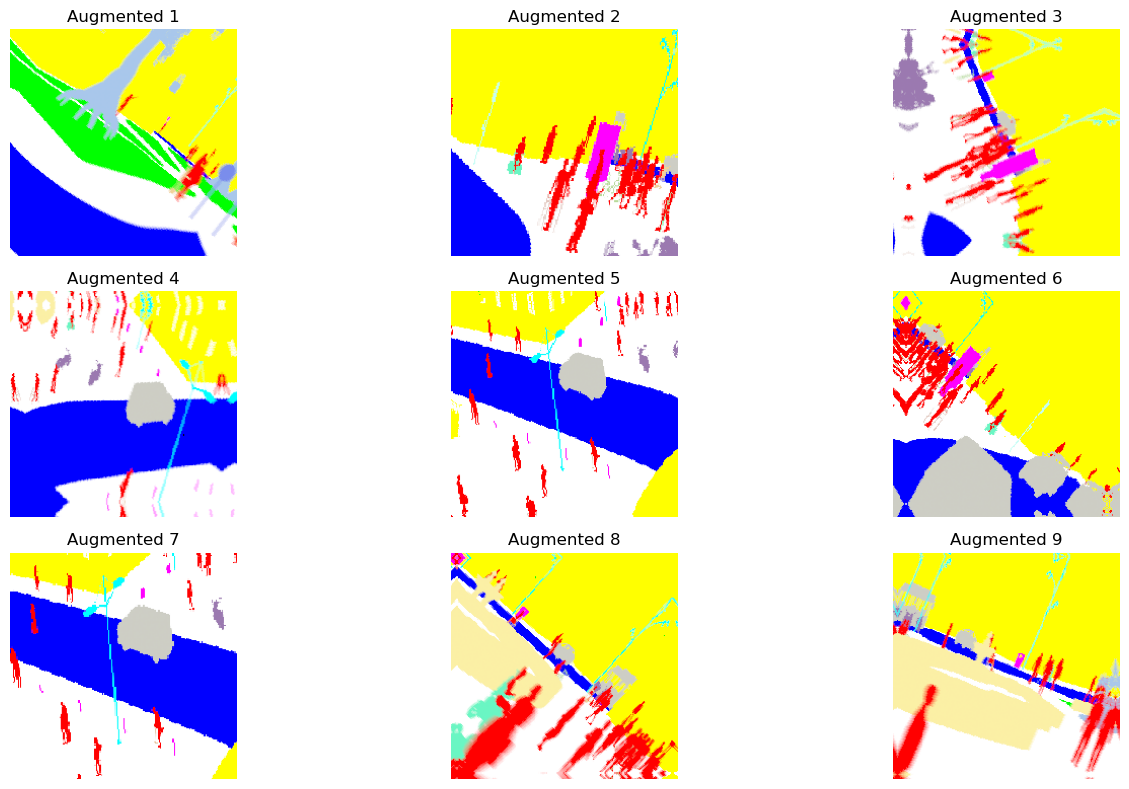

In [11]:
### 5. Tentar visualizar algumas imagens ###
try:
    plt.figure(figsize=(15, 8))
    for i, images in enumerate(train_dataset.take(1)):
        for j in range(min(9, BATCH_SIZE)):
            plt.subplot(3, 3, j+1)
            plt.imshow(images[j])
            plt.title(f'Augmented {j+1}')
            plt.axis('off')
    plt.tight_layout()
    plt.show()
except Exception as e:
    print(f"Erro ao visualizar imagens: {str(e)}")

In [12]:
### 6. Informações úteis sobre o dataset ###
print(f"\nNúmero total de máscaras: {mask_count}")
print(f"Número de batches: {tf.data.experimental.cardinality(train_dataset)}")


Número total de imagens: 5036
Número de batches: 158


In [13]:
"""
Construção do modelo de treinamento
1) Carregar as imagens e as máscaras
2) Construir modelo simples
3) Construir previsão
4) Plotar pequena quantidade de amostras (3)
"""


'\nConstrução do modelo de treinamento\n1) Carregar as imagens e as máscaras\n2) Construir modelo simples\n3) Construir previsão\n4) Plotar pequena quantidade de amostras (3)\n'

In [42]:

def unet_model(input_size=(224, 224, 3)):
    inputs = tf.keras.layers.Input(shape=input_size)

    # Encoder
    conv1 = tf.keras.layers.Conv2D(64, (3, 3), activation='relu', padding='same')(inputs)
    conv1 = tf.keras.layers.Conv2D(64, (3, 3), activation='relu', padding='same')(conv1)
    pool1 = tf.keras.layers.MaxPooling2D((2, 2))(conv1)

    conv2 = tf.keras.layers.Conv2D(128, (3, 3), activation='relu', padding='same')(pool1)
    conv2 = tf.keras.layers.Conv2D(128, (3, 3), activation='relu', padding='same')(conv2)
    pool2 = tf.keras.layers.MaxPooling2D((2, 2))(conv2)

    # Bottleneck
    conv3 = tf.keras.layers.Conv2D(256, (3, 3), activation='relu', padding='same')(pool2)
    conv3 = tf.keras.layers.Conv2D(256, (3, 3), activation='relu', padding='same')(conv3)

    # Decoder
    up1 = tf.keras.layers.UpSampling2D((2, 2))(conv3)
    concat1 = tf.keras.layers.Concatenate()([up1, conv2])
    conv4 = tf.keras.layers.Conv2D(128, (3, 3), activation='relu', padding='same')(concat1)
    conv4 = tf.keras.layers.Conv2D(128, (3, 3), activation='relu', padding='same')(conv4)

    up2 = tf.keras.layers.UpSampling2D((2, 2))(conv4)
    concat2 = tf.keras.layers.Concatenate()([up2, conv1])
    conv5 = tf.keras.layers.Conv2D(64, (3, 3), activation='relu', padding='same')(concat2)
    conv5 = tf.keras.layers.Conv2D(64, (3, 3), activation='relu', padding='same')(conv5)

    outputs = tf.keras.layers.Conv2D(1, (1, 1), activation='sigmoid')(conv5)

    model = tf.keras.Model(inputs, outputs)
    return model

model = unet_model()
model.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_11 (Conv2D)  │ (None, 224, 224,  │      1,792 │ input_layer_3[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_12 (Conv2D)  │ (None, 224, 224,  │     36,928 │ conv2d_11[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 112, 112,  │          0 │ conv2d_12[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_13 (Conv2D)  │ (None, 112, 112,  │     73,856 │ max_pooling2d_2[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_14 (Conv2D)  │ (None, 112, 112,  │    147,584 │ conv2d_13[0][0]   │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_3     │ (None, 56, 56,    │          0 │ conv2d_14[0][0]   │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_15 (Conv2D)  │ (None, 56, 56,    │    295,168 │ max_pooling2d_3[… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_16 (Conv2D)  │ (None, 56, 56,    │    590,080 │ conv2d_15[0][0]   │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d_2     │ (None, 112, 112,  │          0 │ conv2d_16[0][0]   │
│ (UpSampling2D)      │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_2       │ (None, 112, 112,  │          0 │ up_sampling2d_2[… │
│ (Concatenate)       │ 384)              │            │ conv2d_14[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_17 (Conv2D)  │ (None, 112, 112,  │    442,496 │ concatenate_2[0]… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_18 (Conv2D)  │ (None, 112, 112,  │    147,584 │ conv2d_17[0][0]   │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d_3     │ (None, 224, 224,  │          0 │ conv2d_18[0][0]   │
│ (UpSampling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_3       │ (None, 224, 224,  │          0 │ up_sampling2d_3[… │
│ (Concatenate)       │ 192)              │            │ conv2d_12[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_19 (Conv2D)  │ (None, 224, 224,  │    110,656 │ concatenate_3[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_20 (Conv2D)  │ (None, 224, 224,  │     36,928 │ conv2d_19[0][0] 

 Total params: 1,883,137 (7.18 MB)

 Trainable params: 1,883,137 (7.18 MB)

 Non-trainable params: 0 (0.00 B)

In [43]:
# Definir la métrica de IoU (Intersection over Union)
class MeanIoU(tf.keras.metrics.MeanIoU):
    def __init__(self, num_classes, name="mean_iou", **kwargs):
        super().__init__(num_classes=num_classes, name=name, **kwargs)

# Compilar el modelo
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
              loss=tf.keras.losses.BinaryCrossentropy(),
              metrics=['accuracy', MeanIoU(num_classes=2)])

In [37]:
# Crear dataset de imágenes y máscaras
image_dataset = tf.data.Dataset.from_tensor_slices(image_files)
mask_dataset = tf.data.Dataset.from_tensor_slices(mask_files)

# Combinar imágenes y máscaras
dataset = tf.data.Dataset.zip((image_dataset, mask_dataset))

# Función de preprocesamiento para imágenes y máscaras
def load_and_preprocess_image_mask(image_path, mask_path):
    # Cargar imagen
    image = tf.io.read_file(image_path)
    image = tf.image.decode_png(image, channels=3)
    image = tf.image.resize(image, [224, 224])
    image = tf.cast(image, tf.float32) / 255.0  # Normalizar a [0,1]

    # Cargar máscara
    mask = tf.io.read_file(mask_path)
    mask = tf.image.decode_png(mask, channels=1)
    mask = tf.image.resize(mask, [224, 224])
    mask = tf.cast(mask, tf.float32) / 255.0  # Normalizar a [0,1]

    return image, mask

# Aplicar la función de preprocesamiento
train_dataset = dataset.map(
    load_and_preprocess_image_mask,
    num_parallel_calls=tf.data.AUTOTUNE
)

# Aplicar aumento de datos
def augment_tf(image, mask):
    # Generar semillas de tipo int32
    seed = tf.random.uniform(shape=[2], minval=0, maxval=100000, dtype=tf.int32)

    # Aplicar flip horizontal de manera consistente
    image = tf.image.stateless_random_flip_left_right(image, seed=seed)
    mask = tf.image.stateless_random_flip_left_right(mask, seed=seed)

    # Aplicar brillo aleatorio solo a la imagen
    image = tf.image.stateless_random_brightness(image, max_delta=0.1, seed=seed)

    return image, mask

# Aplicar aumentos de datos y configurar el pipeline de entrenamiento
train_dataset = (train_dataset
    .map(augment_tf, num_parallel_calls=tf.data.AUTOTUNE)  # Aplicar aumentos
    .shuffle(BUFFER_SIZE)  # Mezclar datos
    .batch(BATCH_SIZE)  # Agrupar en lotes
    .prefetch(tf.data.AUTOTUNE)  # Optimización de carga de datos
)

# Verificar número de imágenes procesadas
print(f"Total de imágenes procesadas: {len(image_files)}")

# Verificación de la estructura del dataset
for img, mask in train_dataset.take(1):
    print(f"Shape de la imagen en batch: {img.shape}")
    print(f"Shape de la máscara en batch: {mask.shape}")


Total de imágenes procesadas: 5036
Shape de la imagen en batch: (32, 224, 224, 3)
Shape de la máscara en batch: (32, 224, 224, 1)


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.08639902..0.9105546].


Shape de la imagen: (32, 224, 224, 3)
Shape de la máscara: (32, 224, 224, 1)


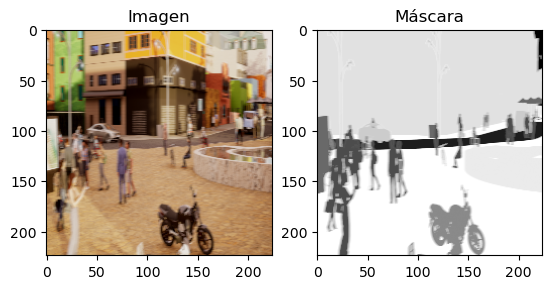

In [41]:
for img, mask in train_dataset.take(1):
    print(f"Shape de la imagen: {img.shape}")
    print(f"Shape de la máscara: {mask.shape}")
    plt.subplot(1,2,1)
    plt.imshow(img[0])
    plt.title("Imagen")
    plt.subplot(1,2,2)
    plt.imshow(mask[0].numpy().squeeze(), cmap='gray')
    plt.title("Máscara")
    plt.show()

In [44]:
EPOCHS = 25

# Entrenamiento del modelo
history = model.fit(
    train_dataset,
    epochs=EPOCHS,
    steps_per_epoch=len(image_files) // BATCH_SIZE,
    verbose=1
)

Epoch 1/25
  9/157 ━━━━━━━━━━━━━━━━━━━━ 28:48 12s/step - accuracy: 0.2501 - loss: 0.7213 - mean_iou: 0.3726

KeyboardInterrupt: 